In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("Dataset_Day3.csv")

df["distance"] = np.sqrt(
    (df["dropoff_longitude"] - df["pickup_longitude"])**2 + (df["dropoff_latitude"] - df["pickup_latitude"])**2
)

print(df.head())

        key  fare_amount          pickup_datetime  pickup_longitude  \
0  24238194          7.5  2015-05-07 19:52:06 UTC        -73.999817   
1  27835199          7.7  2009-07-17 20:04:56 UTC        -73.994355   
2  44984355         12.9  2009-08-24 21:45:00 UTC        -74.005043   
3  25894730          5.3  2009-06-26 08:22:21 UTC        -73.976124   
4  17610152         16.0  2014-08-28 17:47:00 UTC        -73.925023   

   pickup_latitude  dropoff_longitude  dropoff_latitude  passenger_count  \
0        40.738354         -73.999512         40.723217                1   
1        40.728225         -73.994710         40.750325                1   
2        40.740770         -73.962565         40.772647                1   
3        40.790844         -73.965316         40.803349                3   
4        40.744085         -73.973082         40.761247                5   

   distance  
0  0.015140  
1  0.022103  
2  0.053109  
3  0.016528  
4  0.051031  


In [ ]:
# Function to get outliers
def get_outliers(df, col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    return df[
        (df[col] < (Q1 - 1.5 * IQR)) |
        (df[col] > (Q3 + 1.5 * IQR))
    ].index


# Combine outliers from all columns
outliers = get_outliers(df, 'fare_amount').union(
    get_outliers(df, 'passenger_count')
).union(
    get_outliers(df, 'distance')
)

# Remove outliers
df_cleaned = df.drop(outliers)

print("\nData after removing outliers:")
print(df_cleaned.head())


Data after removing outliers:
        key  fare_amount          pickup_datetime  pickup_longitude  \
0  24238194          7.5  2015-05-07 19:52:06 UTC        -73.999817   
1  27835199          7.7  2009-07-17 20:04:56 UTC        -73.994355   
2  44984355         12.9  2009-08-24 21:45:00 UTC        -74.005043   
3  25894730          5.3  2009-06-26 08:22:21 UTC        -73.976124   
5  44470845          4.9  2011-02-12 02:27:09 UTC        -73.969019   

   pickup_latitude  dropoff_longitude  dropoff_latitude  passenger_count  \
0        40.738354         -73.999512         40.723217                1   
1        40.728225         -73.994710         40.750325                1   
2        40.740770         -73.962565         40.772647                1   
3        40.790844         -73.965316         40.803349                3   
5        40.755910         -73.969019         40.755910                1   

   distance  
0  0.015140  
1  0.022103  
2  0.053109  
3  0.016528  
5  0.000000  


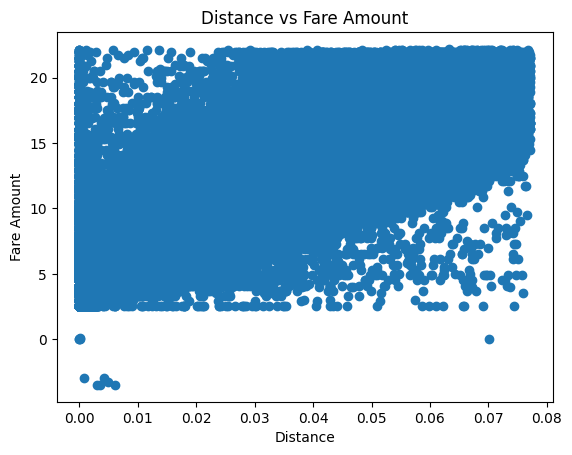

In [9]:
import matplotlib.pyplot as plt

plt.scatter(df_cleaned["distance"], df_cleaned["fare_amount"])

plt.xlabel("Distance")
plt.ylabel("Fare Amount")

plt.title("Distance vs Fare Amount")

plt.show()

In [ ]:
# There is a positive relationship between distance and fare amount.
# As distance increases, fare amount also generally increases.